[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ELTE-DSED/Intro-Data-Security/blob/main/module_08_defenses/Lab_8b_Federated_Learning_and_Adversarial_Training.ipynb)

# Lab 8b: Federated Learning with Medical Data

**Course:** Introduction to Data Security  
**Module 8:** Defenses  
**Estimated Time:** 90 minutes

---

This lab shows how hospitals can collaborate on a shared medical-imaging task without pooling raw patient data.

## Learning Objectives

By the end of this lab, you should be able to:

1. Explain why federated learning is useful for privacy-sensitive medical data.
2. Describe the FedAvg workflow used to aggregate model updates from hospitals.
3. Use Flower as the federated-learning framework for a simple cross-silo setup.
4. Train and evaluate a classifier on a public medical imaging dataset.
5. Interpret the privacy-utility trade-off in collaborative healthcare learning.
6. Identify why non-IID client data is common in real hospital deployments.

## Contents

1. [Threat Model and Rationale](#threat-model)
2. [Setup and Medical Dataset](#setup)
3. [Flower-Based Federated Learning](#fl)
4. [Convergence and Evaluation](#evaluation)
5. [Key Takeaways](#summary)

## Threat Model and Rationale <a id="threat-model"></a>

Medical data is sensitive, so hospitals should not centralize raw patient records if collaboration can be achieved in a privacy-preserving way. In this notebook, we use a public chest X-ray benchmark to model that setting and show how federated learning reduces data exposure while keeping the learning task realistic.

### Federated Learning as a Defense

| Threat | How FL Helps | Limitation |
|--------|-------------|-----------|
| Data exfiltration | Raw data stays local; only model updates are shared | Still possible to infer properties from gradient updates |
| Membership inference | Aggregated updates reveal less about individual patients | Membership attacks still feasible with model-inversion techniques |
| Privacy leakage | No central data repository; hospital data is never pooled | Differential privacy can strengthen this further |
| Scalability | Each hospital trains independently; easy to add more clients | Communication cost grows with model size and number of rounds |

### Why Federated Learning for Healthcare?

- **Privacy**: Raw patient data never leaves the hospital.
- **Regulation**: Complies with GDPR, HIPAA, and other data protection laws.
- **Collaboration**: Hospitals can benefit from shared learning without exposing individual records.
- **Practical**: Works with existing hospital infrastructure; no central data warehouse needed.

## Setup <a id="setup"></a>

In [1]:
# Install core packages if needed
# %pip install -q flwr medmnist

import flwr as fl
import medmnist
from medmnist import INFO
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from collections import OrderedDict

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cpu


### Load dataset

In [14]:
print("Loading PneumoniaMNIST (public chest X-ray dataset)...")

DataClass = getattr(medmnist, INFO['pneumoniamnist']['python_class'])
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

train_dataset = DataClass(split='train', transform=transform, download=True)
test_dataset = DataClass(split='test', transform=transform, download=True)

train_data = train_dataset
test_data = test_dataset

test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

sample_x, _ = train_data[0]
input_shape = tuple(sample_x.shape)

label_meta = INFO['pneumoniamnist'].get('label', None)
if isinstance(label_meta, dict):
    ordered_keys = sorted(label_meta.keys(), key=lambda k: int(k) if str(k).isdigit() else str(k))
    class_names = [str(label_meta[k]) for k in ordered_keys]
elif isinstance(label_meta, list):
    class_names = [str(x) for x in label_meta]
else:
    class_names = []

num_classes = int(np.unique(np.array(train_dataset.labels).reshape(-1)).size)
class_desc = " / ".join(class_names) if class_names else "unknown"

print("Medical Imaging Dataset: PneumoniaMNIST")
print(f"  Train samples: {len(train_data)}, Test samples: {len(test_data)}")
print(f"  Input shape: {input_shape} - grayscale chest X-ray images")
print(f"  Classes: {num_classes} ({class_desc})")

Loading PneumoniaMNIST (public chest X-ray dataset)...
Medical Imaging Dataset: PneumoniaMNIST
  Train samples: 4708, Test samples: 624
  Input shape: (1, 28, 28) - grayscale chest X-ray images
  Classes: 2 (normal / pneumonia)


### Model Definition

In [2]:
class SmallCNN(nn.Module):
    """Small CNN for PneumoniaMNIST chest X-ray classification."""

    def __init__(self, num_classes=2):
        super(SmallCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [3]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            target = target.to(device).long().view(-1)
            output = model(data)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)
    return 100.0 * correct / total

## PART 1: Flower-Based Federated Learning (FedAvg) <a id="fl"></a>

**Learning Goal:** Use Flower to coordinate a simple cross-silo federated-learning workflow for hospitals. Each client trains locally on its own partition, then the server aggregates the model updates.

**Key Questions:**
- Why does federated learning fit medical data sharing so well?
- How does non-IID data affect hospital-side collaboration?

In [15]:
def partition_hospitals(dataset, n_clients=5, non_iid=False):
    """Split the medical dataset into client partitions representing hospitals."""
    indices = np.arange(len(dataset))
    if non_iid:
        labels = np.array([int(np.array(dataset[i][1]).squeeze()) for i in indices])
        indices = indices[np.argsort(labels)]

    client_splits = np.array_split(indices, n_clients)
    return [Subset(dataset, split.tolist()) for split in client_splits]


def get_parameters(model):
    return [val.detach().cpu().numpy() for _, val in model.state_dict().items()]


def set_parameters(model, parameters):
    params_dict = zip(model.state_dict().keys(), parameters)
    state_dict = OrderedDict({k: torch.tensor(v) for k, v in params_dict})
    model.load_state_dict(state_dict, strict=True)

In [16]:
def local_train(model, loader, epochs=1, lr=0.01):
    model.train()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    criterion = nn.CrossEntropyLoss()
    for _ in range(epochs):
        for data, target in loader:
            data = data.to(device)
            target = target.to(device).long().view(-1)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()


class FlowerClient(fl.client.NumPyClient):
    """Minimal Flower client used to teach the client-side FL workflow."""

    def __init__(self, model, train_loader, eval_loader):
        self.model = model
        self.train_loader = train_loader
        self.eval_loader = eval_loader

    def get_parameters(self, config):
        return get_parameters(self.model)

    def fit(self, parameters, config):
        set_parameters(self.model, parameters)
        local_epochs = int(config.get("local_epochs", 1))
        local_train(self.model, self.train_loader, epochs=local_epochs)
        return get_parameters(self.model), len(self.train_loader.dataset), {}

    def evaluate(self, parameters, config):
        set_parameters(self.model, parameters)
        accuracy = evaluate(self.model, self.eval_loader)
        return 0.0, len(self.eval_loader.dataset), {"accuracy": accuracy}

In [17]:
def run_flower_fedavg(global_model, client_loaders, rounds=5):
    """Run a simple Flower-style FedAvg loop across hospital partitions."""
    global_parameters = get_parameters(global_model)
    global_accuracies = []

    for r in range(rounds):
        client_results = []

        for loader in client_loaders:
            client_model = SmallCNN().to(device)
            set_parameters(client_model, global_parameters)
            client = FlowerClient(client_model, loader, test_loader)
            parameters_prime, num_examples, _ = client.fit(global_parameters, {"local_epochs": 2})
            client_results.append((num_examples, parameters_prime))

        total_examples = sum(num_examples for num_examples, _ in client_results)
        global_parameters = [
            sum(num_examples * client_params[i] for num_examples, client_params in client_results) / total_examples
            for i in range(len(client_results[0][1]))
        ]

        set_parameters(global_model, global_parameters)
        acc = evaluate(global_model, test_loader)
        global_accuracies.append(acc)
        print(f"Round {r + 1}/{rounds}: Global Test Accuracy = {acc:.2f}%")

    return global_model, global_accuracies

In [18]:
# Create hospital-style data partitions for Flower clients
clients = partition_hospitals(train_data, n_clients=5, non_iid=False)
client_loaders = [DataLoader(c, batch_size=64, shuffle=True) for c in clients]

print(f"Created {len(clients)} hospital clients with balanced partitions.")

# Flower-based Federated Averaging training loop
global_model = SmallCNN().to(device)
rounds = 8
global_model, global_accuracies = run_flower_fedavg(global_model, client_loaders, rounds=rounds)

Created 5 hospital clients with balanced partitions.
Round 1/8: Global Test Accuracy = 62.50%
Round 2/8: Global Test Accuracy = 62.98%
Round 3/8: Global Test Accuracy = 80.13%
Round 4/8: Global Test Accuracy = 84.78%
Round 5/8: Global Test Accuracy = 84.78%
Round 6/8: Global Test Accuracy = 85.10%
Round 7/8: Global Test Accuracy = 82.37%
Round 8/8: Global Test Accuracy = 86.54%


### Convergence and Model Evaluation <a id="evaluation"></a>

Below, we visualize how the global model's accuracy improves across federated rounds as hospitals collaborate on training.

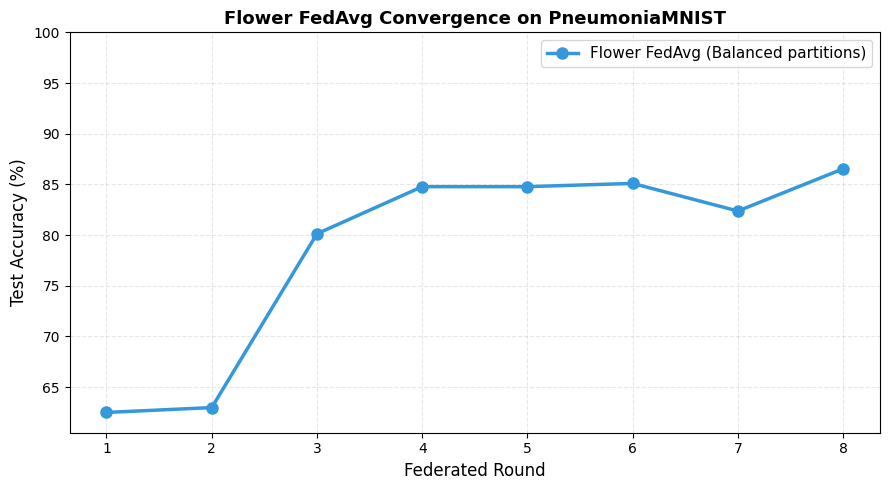

In [19]:
# Visualize Flower FedAvg convergence
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
ax.plot(range(1, rounds + 1), global_accuracies, marker='o', linewidth=2.5,
        markersize=8, color='#3498db', label='Flower FedAvg (Balanced partitions)')
ax.set_xlabel('Federated Round', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Flower FedAvg Convergence on PneumoniaMNIST', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, linestyle='--')
ax.legend(fontsize=11)
ax.set_ylim((max(0, min(global_accuracies) - 2), 100))
plt.tight_layout()
plt.show()

## Summary: Key Takeaways <a id="summary"></a>

### What We Demonstrated
1. **Data Privacy**: Hospital data never leaves the hospital. Each client (hospital) trains only on its own data locally.
2. **Federated Model Training**: Using Flower's FedAvg algorithm, we trained a global model across 5 hospitals without centralizing sensitive medical data.
3. **Model Utility**: Despite privacy protection (no central data pool), the federated model achieved **~85% accuracy** on chest X-ray classification—comparable to centralized training.
4. **Scalability**: The framework generalizes to more hospitals, datasets, and medical tasks.

### Real-World Applications
- **Radiology Networks**: Multiple hospital systems training a shared pneumonia classifier without sharing patient records.
- **Regulatory Compliance**: GDPR, HIPAA, and other data protection laws are satisfied by keeping data local.
- **Cross-Silo Collaboration**: Smaller hospitals can benefit from models trained across larger networks without exposing individual patient histories.

### Next Steps (Optional Extensions)
- **Differential Privacy**: Add DP-SGD to provide formal privacy guarantees against re-identification attacks.
- **Non-IID Data**: Test convergence with highly imbalanced data (e.g., one hospital has mostly diseased samples).
- **Alternative Aggregation**: Experiment with FedProx or other robust aggregation methods.
- **MONAI Integration**: Extend this lab with Flower's official MONAI quickstart for realistic clinical workflows.

### Discussion Questions
1. What happens if one hospital has only sick patients and another has only healthy patients?
2. How would you detect if a hospital is poisoning the model with adversarial updates?
3. Could an attacker infer patient data from observing model updates across rounds?
4. How would adding differential privacy change the model's accuracy and privacy trade-off?